<a href="https://colab.research.google.com/github/kruthee05/MACHINELEARNING2/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unsupervised Similarity using K-Means Clustering

This section will guide you through reading a dataset, preprocessing it, applying K-Means clustering, and displaying the results.

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load the Dataset ---
# IMPORTANT: Replace '/path/to/your/dataset.csv' with the actual path to your dataset file.
# You can upload a file by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'.
# Right-click the uploaded file and select 'Copy path' to get the correct path.
try:
    # Using a sample dataset for demonstration. Replace with your file path.
    df = pd.read_csv('/content/academic_survival_longitudinal.csv') # Using sample dataset
    print("Dataset loaded successfully. First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: Dataset file not found. Please update the path and try again.")
    df = None # Set df to None to prevent further errors
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    df = None

Dataset loaded successfully. First 5 rows:


,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,...,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored
0,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,1,...,0.0,2.85,85.8,67.0,0,0,1.7,0,Enrolled,0
1,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,2,...,0.0,2.73,81.0,89.0,1,0,3.1,0,Enrolled,0
2,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,3,...,0.0,2.60,78.3,60.0,0,2,3.0,0,Enrolled,0
3,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,4,...,0.0,2.34,77.2,59.0,2,3,5.1,0,Enrolled,0
4,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,5,...,0.0,1.90,79.3,53.0,1,2,3.6,0,Enrolled,1


### Preprocessing the Data

Before applying K-Means, it's crucial to preprocess the data. This usually involves handling missing values (if any) and scaling the features. K-Means is sensitive to the scale of the features, so `StandardScaler` is commonly used.

In [8]:
if df is not None:
    # Identify numerical columns for scaling. Exclude any non-numeric columns that aren't relevant for clustering.
    numeric_cols = df.select_dtypes(include=['number']).columns

    if not numeric_cols.empty:
        # Handle missing values by filling with the mean (a common strategy, but may need adjustment)
        df_processed = df[numeric_cols].fillna(df[numeric_cols].mean())

        # Initialize StandardScaler
        scaler = StandardScaler()

        # Fit and transform the numerical features
        scaled_features = scaler.fit_transform(df_processed)

        # Create a DataFrame from scaled features
        df_scaled = pd.DataFrame(scaled_features, columns=numeric_cols)
        print("Data preprocessed and scaled. First 5 rows of scaled data:")
        display(df_scaled.head())
    else:
        print("No numerical columns found for clustering after initial load. Please ensure your dataset contains numerical features or adjust column selection.")
        df_scaled = None
else:
    print("Skipping preprocessing as dataset was not loaded.")
    df_scaled = None

Data preprocessed and scaled. First 5 rows of scaled data:


,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored
0,-0.697483,-0.69847,-1.200522,-0.890981,-0.619767,-0.905536,-1.102497,0.048275,0.136499,-0.276778,0.375067,0.111973,0.049312,-0.710663,-0.830082,-0.483141,-0.30926,-0.403929
1,-0.697483,-0.69847,-1.200522,-0.890981,-0.619767,-0.905536,-0.588673,0.048275,0.574751,-0.276778,0.091171,-0.636177,1.786949,0.777543,-0.830082,0.286992,-0.30926,-0.403929
2,-0.697483,-0.69847,-1.200522,-0.890981,-0.619767,-0.905536,-0.074850,0.048275,0.201771,-0.276778,-0.216384,-1.057011,-0.503573,-0.710663,1.714252,0.231982,-0.30926,-0.403929
3,-0.697483,-0.69847,-1.200522,-0.890981,-0.619767,-0.905536,0.438973,0.048275,0.891785,-0.276778,-0.831492,-1.228462,-0.582556,2.265749,2.986418,1.387181,-0.30926,-0.403929
4,-0.697483,-0.69847,-1.200522,-0.890981,-0.619767,-0.905536,0.952796,1.348500,0.789215,-0.276778,-1.872446,-0.901147,-1.056457,0.777543,1.714252,0.562039,-0.30926,2.475685


### Applying K-Means Clustering

Now, we'll apply the K-Means algorithm. You'll need to choose the number of clusters (`n_clusters`). If you're unsure, methods like the "Elbow Method" can help in determining an optimal `k`.

For demonstration, we'll start with a arbitrary number of clusters (e.g., 3). You can modify `n_clusters` as needed.

In [9]:
if df_scaled is not None and not df_scaled.empty:
    # Choose the number of clusters
    n_clusters = 3  # You can change this value

    # Initialize KMeans model
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init is specified to suppress a warning

    # Fit KMeans to the scaled data
    kmeans.fit(df_scaled)

    # Get cluster assignments
    df['cluster'] = kmeans.labels_

    print(f"K-Means clustering performed with {n_clusters} clusters. Cluster assignments added to the original DataFrame.")
    print("Cluster distribution:")
    display(df['cluster'].value_counts())
    print("First 5 rows of the DataFrame with cluster assignments:")
    display(df.head())
else:
    print("Skipping K-Means clustering as scaled data is not available.")

K-Means clustering performed with 3 clusters. Cluster assignments added to the original DataFrame.
Cluster distribution:


,count
cluster,
0,43198
1,25153
2,10888


First 5 rows of the DataFrame with cluster assignments:


,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,...,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored,cluster
0,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,1,...,2.85,85.8,67.0,0,0,1.7,0,Enrolled,0,0
1,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,2,...,2.73,81.0,89.0,1,0,3.1,0,Enrolled,0,0
2,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,3,...,2.60,78.3,60.0,0,2,3.0,0,Enrolled,0,1
3,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,4,...,2.34,77.2,59.0,2,3,5.1,0,Enrolled,0,1
4,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,5,...,1.90,79.3,53.0,1,2,3.6,0,Enrolled,1,2


### Visualizing Clusters (Optional - requires 2D/3D data or dimensionality reduction)

If your data has 2 or 3 principal components, you can visualize the clusters directly. For higher dimensions, you might need to use techniques like PCA or t-SNE to reduce dimensionality for visualization. This example assumes a simple 2-feature visualization for illustration.

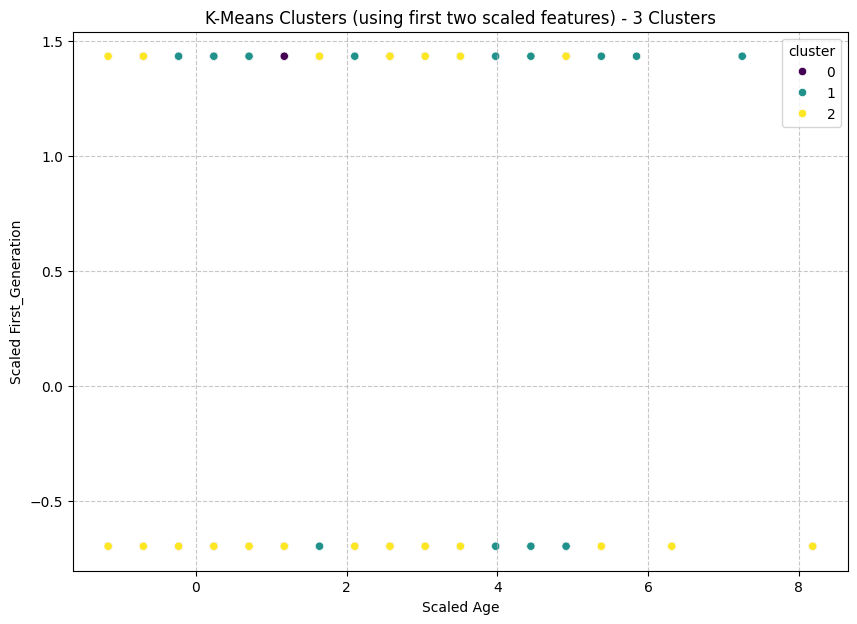

In [10]:
if df is not None and 'cluster' in df.columns and len(numeric_cols) >= 2:
    # For simplicity, let's try to visualize using the first two numerical features if available
    # If you have high-dimensional data, consider PCA for dimensionality reduction first.

    fig = plt.figure(figsize=(10, 7))
    sns.scatterplot(x=df_scaled.iloc[:, 0], y=df_scaled.iloc[:, 1], hue=df['cluster'], palette='viridis', legend='full')
    plt.title(f'K-Means Clusters (using first two scaled features) - {n_clusters} Clusters')
    plt.xlabel(f'Scaled {numeric_cols[0]}')
    plt.ylabel(f'Scaled {numeric_cols[1]}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
elif df is not None and 'cluster' not in df.columns:
    print("Visualization skipped: Clustering was not performed.")
elif df is not None and len(numeric_cols) < 2:
    print("Visualization skipped: Not enough numerical features (at least 2) for a simple 2D scatter plot.")
else:
    print("Visualization skipped: Data not loaded or processed.")